

# Import the dataset

In [91]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/countries of the world.csv


In [92]:
data_frame = pd.read_csv("/kaggle/input/countries of the world.csv")

In [93]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Country                             227 non-null    object 
 1   Region                              227 non-null    object 
 2   Population                          227 non-null    int64  
 3   Area (sq. mi.)                      227 non-null    int64  
 4   Pop. Density (per sq. mi.)          227 non-null    object 
 5   Coastline (coast/area ratio)        227 non-null    object 
 6   Net migration                       224 non-null    object 
 7   Infant mortality (per 1000 births)  224 non-null    object 
 8   GDP ($ per capita)                  226 non-null    float64
 9   Literacy (%)                        209 non-null    object 
 10  Phones (per 1000)                   223 non-null    object 
 11  Arable (%)                          225 non-n

In [94]:
data_frame.head()

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,"48,0","0,00","23,06","163,07",700.0,"36,0","3,2","12,13","0,22","87,65",1,"46,6","20,34","0,38","0,24","0,38"
1,Albania,EASTERN EUROPE,3581655,28748,"124,6","1,26","-4,93","21,52",4500.0,"86,5","71,2","21,09","4,42","74,49",3,"15,11","5,22","0,232","0,188","0,579"
2,Algeria,NORTHERN AFRICA,32930091,2381740,"13,8","0,04","-0,39",31,6000.0,"70,0","78,1","3,22","0,25","96,53",1,"17,14","4,61","0,101","0,6","0,298"
3,American Samoa,OCEANIA,57794,199,"290,4","58,29","-20,71","9,27",8000.0,"97,0","259,5",10,15,75,2,"22,46","3,27",NaN,NaN,NaN
4,Andorra,WESTERN EUROPE,71201,468,"152,1","0,00","6,6","4,05",19000.0,"100,0","497,2","2,22",0,"97,78",3,"8,71","6,25",NaN,NaN,NaN


In [95]:
data_frame.describe()

,Population,Area (sq. mi.),GDP ($ per capita)
count,2.270000e+02,2.270000e+02,226.000000
mean,2.874028e+07,5.982270e+05,9689.823009
std,1.178913e+08,1.790282e+06,10049.138513
min,7.026000e+03,2.000000e+00,500.000000
25%,4.376240e+05,4.647500e+03,1900.000000
50%,4.786994e+06,8.660000e+04,5550.000000
75%,1.749777e+07,4.418110e+05,15700.000000
max,1.313974e+09,1.707520e+07,55100.000000


# Visualize data

Hypothesis_1: Higher literacy leads to higher GDP per capita

Desicion: I noticed that countries with higher literacy rates (like 90%) tend to have higher GDP per capita (like 50,000), while countries with lower literacy rates (like 50%). To comfirm this, I will check the data to see if this pattern is true for most coutries.

In [96]:
# Select relevant columns
data_frame = data_frame[["Country", "GDP ($ per capita)", "Literacy (%)"]]

In [97]:
# Drop rows with missing values
data_frame = data_frame.dropna()

In [98]:
# Clean 'Literacy (%)' column: remove commas and percentage signs, then convert to numeric
data_frame["Literacy (%)"] = data_frame["Literacy (%)"].replace({"%": "", ",": "."}, regex=True).astype(float)

In [99]:
# Clean 'GDP ($ per capita)' column: convert to numeric (handle errors by converting invalid values to NaN)
data_frame["GDP ($ per capita)"] = pd.to_numeric(data_frame["GDP ($ per capita)"], errors='coerce')

In [100]:
# Drop rows again after cleaning for any remaining NaN values
data_frame = data_frame.dropna()

In [101]:
#Preview the cleaned data
print("\nCleaned Data:")
print(data_frame.head())


Cleaned Data:
           Country  GDP ($ per capita)  Literacy (%)
0     Afghanistan                700.0          36.0
1         Albania               4500.0          86.5
2         Algeria               6000.0          70.0
3  American Samoa               8000.0          97.0
4         Andorra              19000.0         100.0


In [102]:
# Compute correlation
correlation = data_frame["Literacy (%)"].corr(data_frame["GDP ($ per capita)"])
print(f"\nCorrelation between Literacy (%) and GDP ($ per capita): {correlation:.2f}")

# Compare average GDP for high and low literacy countries
average_gdp_high_literacy = data_frame[data_frame["Literacy (%)"] > 90]["GDP ($ per capita)"].mean()
average_gdp_low_literacy = data_frame[data_frame["Literacy (%)"] <= 90]["GDP ($ per capita)"].mean()

# Display averages
print(f"Average GDP for countries with high literacy (>90%): ${average_gdp_high_literacy:.2f}")
print(f"Average GDP for countries with low literacy (<=90%): ${average_gdp_low_literacy:.2f}")



Correlation between Literacy (%) and GDP ($ per capita): 0.51
Average GDP for countries with high literacy (>90%): $14285.96
Average GDP for countries with low literacy (<=90%): $4001.05


In [103]:
# Conclusion based on correlation
if correlation > 0.5:
    conclusion = "strong positive relationship"
elif correlation > 0.2:
    conclusion = "moderate positive relationship"
else:
    conclusion = "weak relationship"

print(f"\nConclusion: There is a {conclusion} between literacy rates and GDP per capita.")




Conclusion: There is a strong positive relationship between literacy rates and GDP per capita.


In [104]:
# Check if the hypothesis is supported
if average_gdp_high_literacy > average_gdp_low_literacy:
    print("This supports the hypothesis that higher literacy rates lead to higher GDP per capita.")
else:
    print("This does not support the hypothesis.")


This supports the hypothesis that higher literacy rates lead to higher GDP per capita.


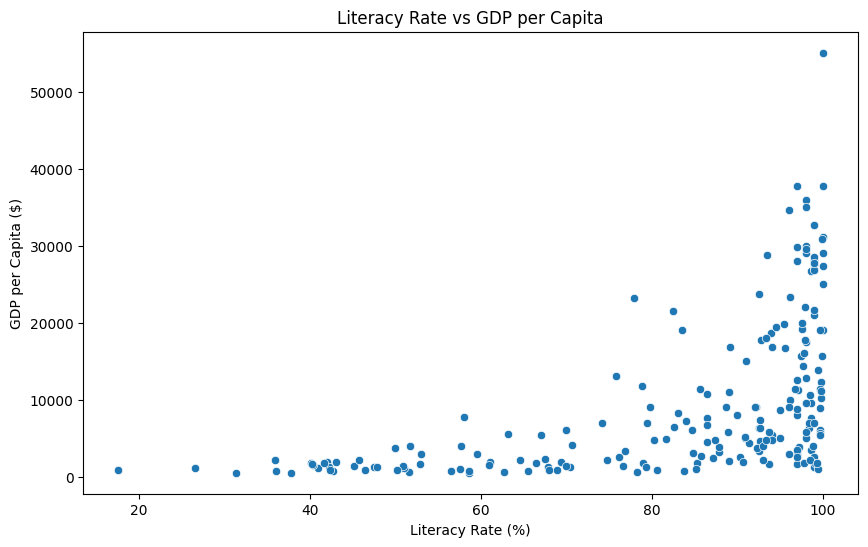

In [105]:
# Scatter plot of Literacy vs GDP
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data_frame["Literacy (%)"], y=data_frame["GDP ($ per capita)"])
plt.xlabel("Literacy Rate (%)")
plt.ylabel("GDP per Capita ($)")
plt.title("Literacy Rate vs GDP per Capita")
plt.show()

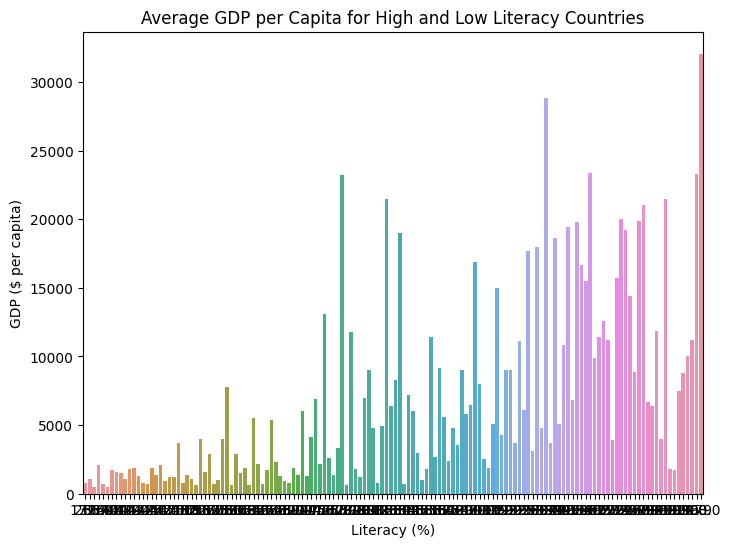

In [106]:
# Bar plot for comparison of average GDP based on literacy rate
avg_gdp_by_literacy = data_frame.groupby("Literacy (%)")['GDP ($ per capita)'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(x='Literacy (%)', y='GDP ($ per capita)', data=avg_gdp_by_literacy)
plt.title('Average GDP per Capita for High and Low Literacy Countries')
plt.show()

In [107]:
# Step 1: Prepare Data for Machine Learning
X = data_frame[['Literacy (%)']]  # Feature: Literacy Rate
y = data_frame['GDP ($ per capita)']  # Target: GDP per Capita

# Split data into training and testing sets (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Step 2: Scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
#prevents larger values from dominating smaller ones, without scalling the model could be biased

# Step 3: Train Linear Regression Model (instead of KNN)
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Predict GDP for the test set
y_pred = regressor.predict(X_test)

# Step 4: Evaluate the Model with R² Score
r2 = r2_score(y_test, y_pred) * 100
print(f"Model R² Score: {r2:.2f}%")


Model R² Score: 23.47%


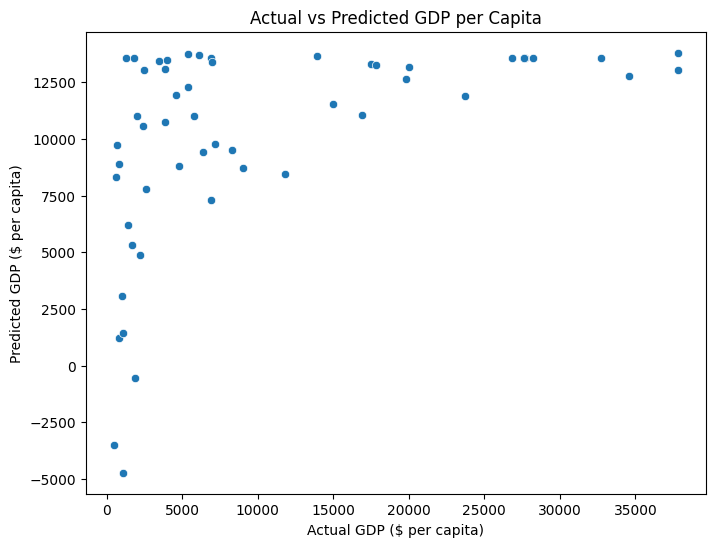

In [108]:
# Scatter plot of actual vs predicted GDP
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual GDP ($ per capita)")
plt.ylabel("Predicted GDP ($ per capita)")
plt.title("Actual vs Predicted GDP per Capita")
plt.show()